In [1]:
import pandas as pd

df = pd.read_csv('../../../datasets/US_with_labels.csv')
df.head()

,spotify_id,name,artists,daily_rank,daily_movement,weekly_movement,country,snapshot_date,popularity,is_explicit,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,average_song
0,2CGNAOSuO1MEFCbBRgUzjd,luther (with sza),"Kendrick Lamar, SZA",1,0,0,US,2025-02-17,90,False,...,-7.546,1,0.1250,0.2510,0.000000,0.2480,0.576,138.008,4,About_Average
1,6AI3ezQ4o3HUoP6Dhudph3,Not Like Us,Kendrick Lamar,2,0,1,US,2025-02-17,92,True,...,-7.001,1,0.0776,0.0107,0.000000,0.1410,0.214,101.061,4,Higher
2,0aB0v4027ukVziUGwVGYpG,tv off (feat. lefty gunplay),"Kendrick Lamar, Lefty Gunplay",3,0,-1,US,2025-02-17,92,True,...,-6.679,0,0.2630,0.0837,0.000000,0.4230,0.548,100.036,4,Higher
3,3GCdLUSnKSMJhs4Tj6CV3s,All The Stars (with SZA),"Kendrick Lamar, SZA",4,0,12,US,2025-02-17,90,True,...,-4.946,1,0.0599,0.0612,0.000195,0.0926,0.557,96.782,4,About_Average
4,0nj9Bq5sHDiTxSHunhgkFb,squabble up,Kendrick Lamar,5,0,4,US,2025-02-17,89,True,...,-5.568,1,0.1980,0.0206,0.000000,0.0783,0.711,103.921,4,Lower


In [16]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["spotify_id", "name", "artists", "snapshot_date", "country", "album_name", "album_release_date", "popularity", 'daily_rank', 'daily_movement', 'weekly_movement'], axis=1, inplace=False)
y = df["popularity"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline

estimator = RandomForestRegressor(n_estimators=100, min_samples_split=2, min_samples_leaf=1, max_features='log2', max_depth=None)
encode = OneHotEncoder()
scaler = MinMaxScaler()


preprocessing = make_column_transformer((encode, ['average_song']), (scaler, [
       'is_explicit', 'duration_ms', 'danceability', 'energy', 'key',
       'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'time_signature'] ), remainder='passthrough')

pipeline = make_pipeline(preprocessing, estimator)
pipeline.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(),
                                                  ['average_song']),
                                                 ('minmaxscaler',
                                                  MinMaxScaler(),
                                                  ['is_explicit', 'duration_ms',
                                                   'danceability', 'energy',
                                                   'key', 'loudness', 'mode',
                                                   'speechiness',
                                                   'acousticness',
                                                   'instrumentalness',
                                                   'liveness', 'valence',
                                                   'tempo',
                                                   'time_signature'])])),
                ('randomforestregressor',
                 RandomForestRegressor(max_features='log2'))])

In [20]:
import shap as shap

fraction_of_data = 1

feature_names = preprocessing.get_feature_names_out()

X_train_transformed = preprocessing.transform(X_train.sample(frac=fraction_of_data))

explainer = shap.Explainer(
    estimator.predict,
    X_train_transformed,
    feature_names=feature_names
)

# TreeExplainer took 2.5 hours with 0.001 fraction
# Explainer took 

small = X_test.sample(frac=fraction_of_data)
X_test_transformed = preprocessing.transform(small)
shap_values = explainer(X_test_transformed)
    
    

PermutationExplainer explainer: 4705it [16:20,  4.75it/s]                          


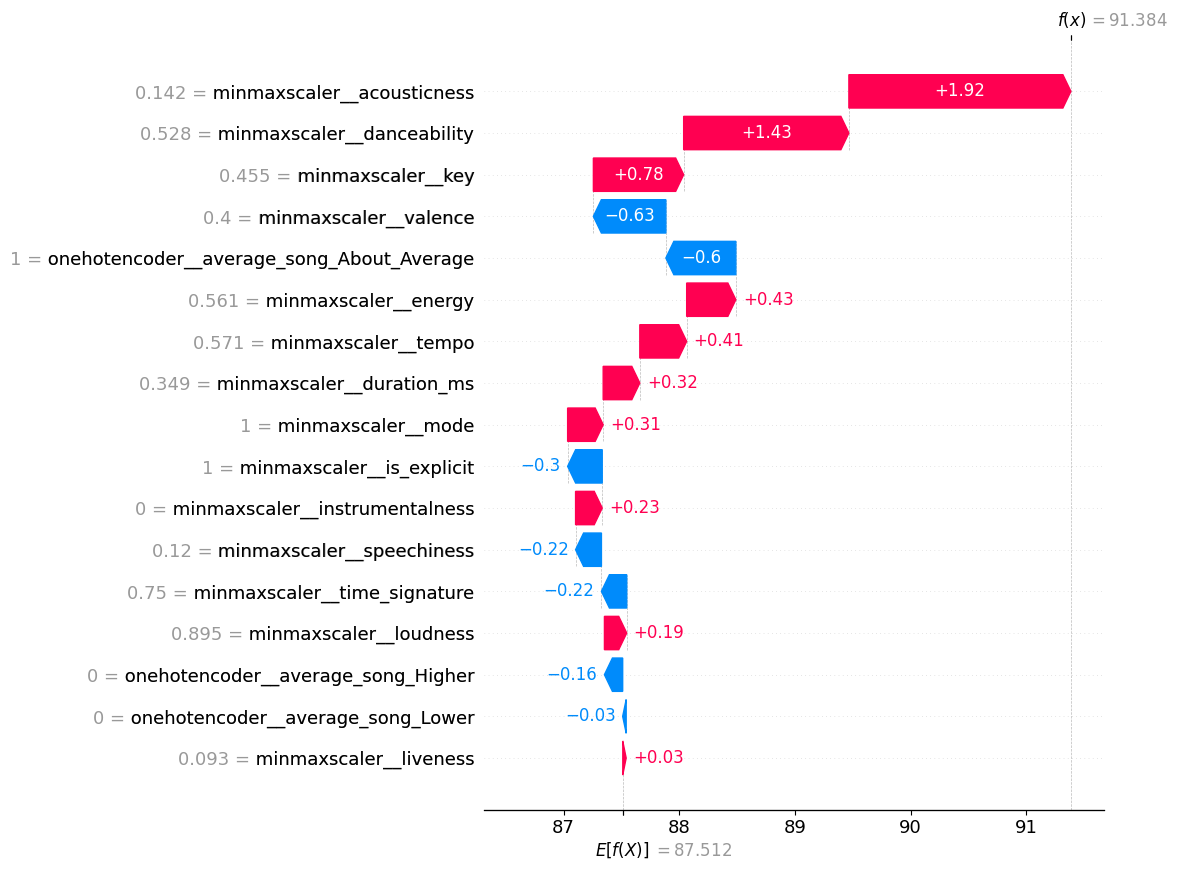

In [21]:
# PLots a single prediction and how it got there
shap.plots.waterfall(shap_values[0], max_display=50)


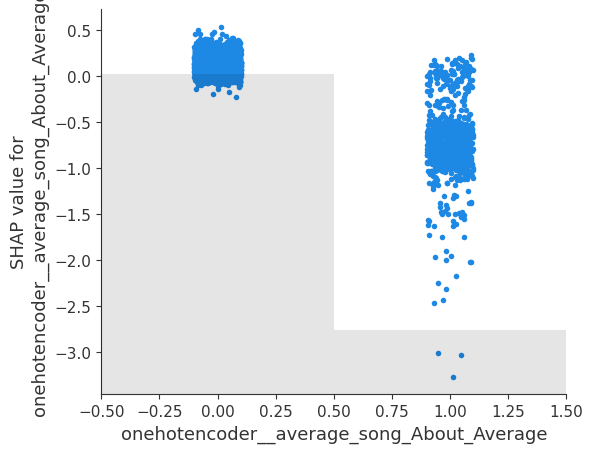

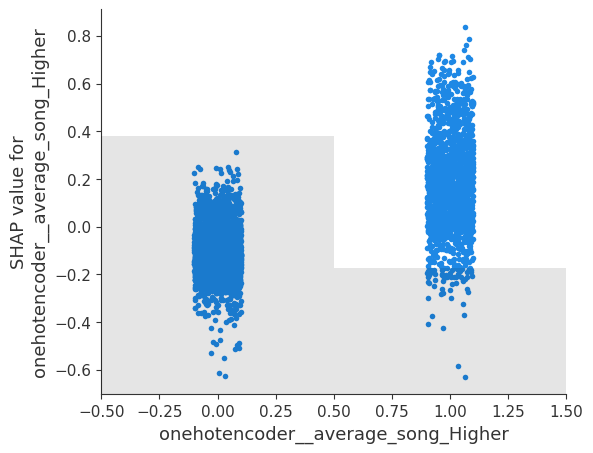

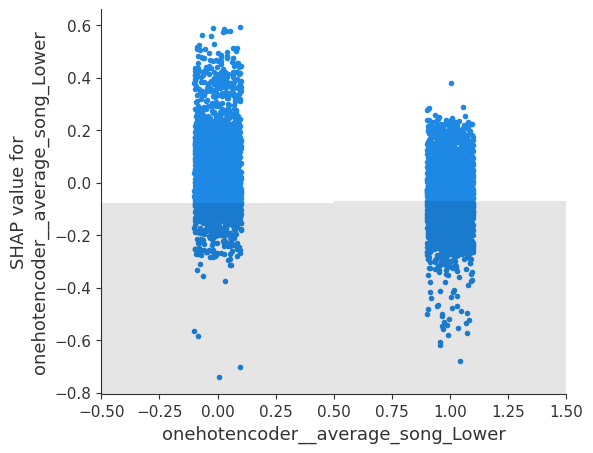

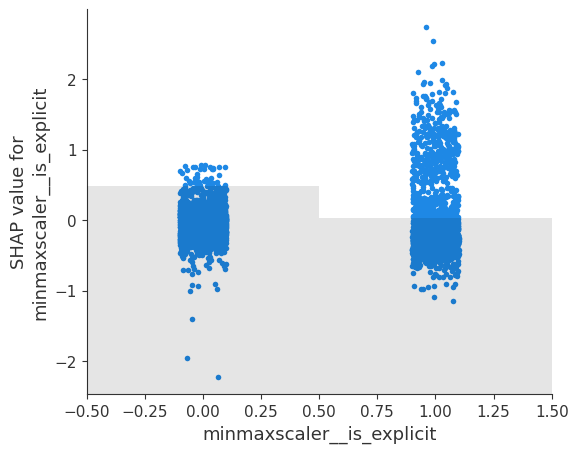

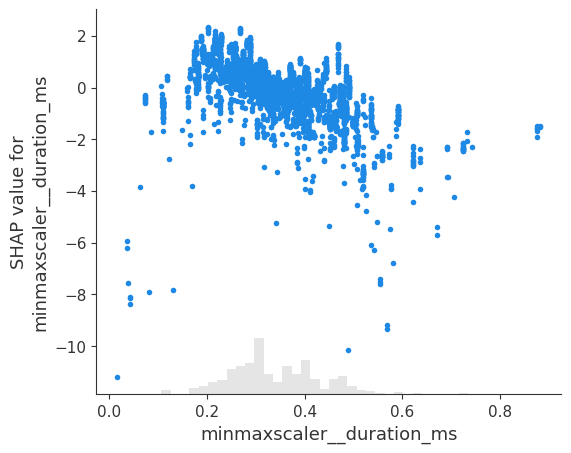

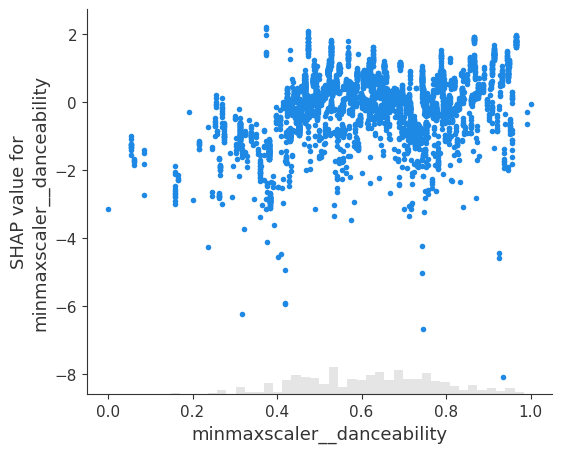

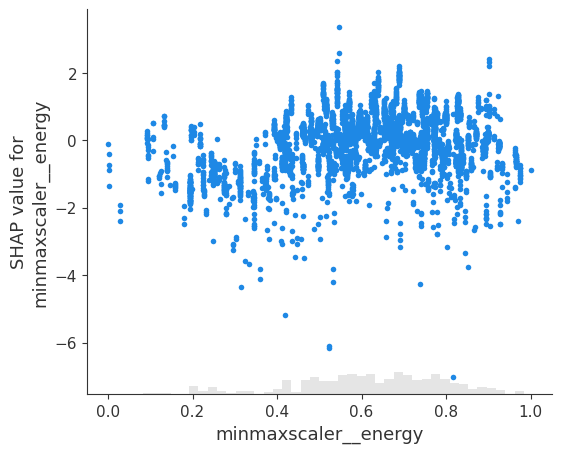

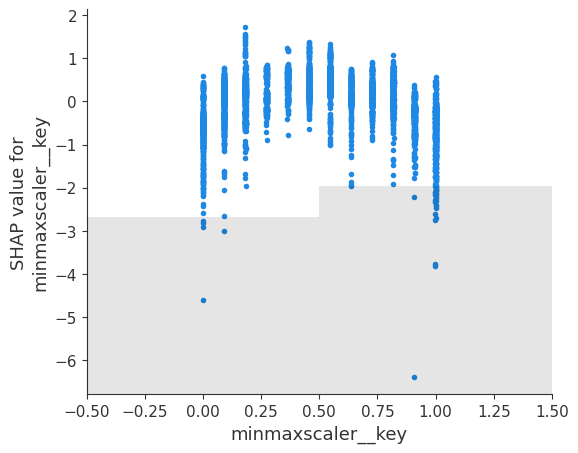

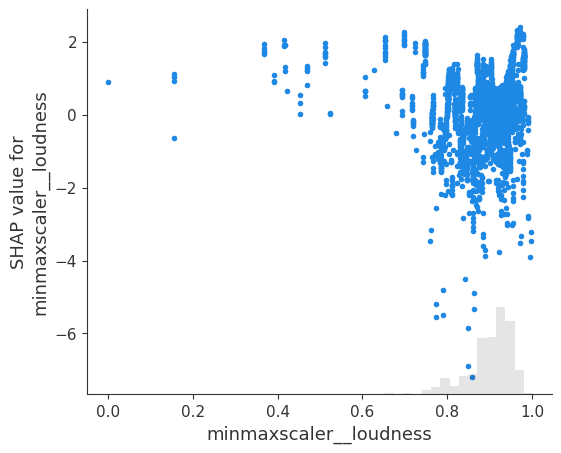

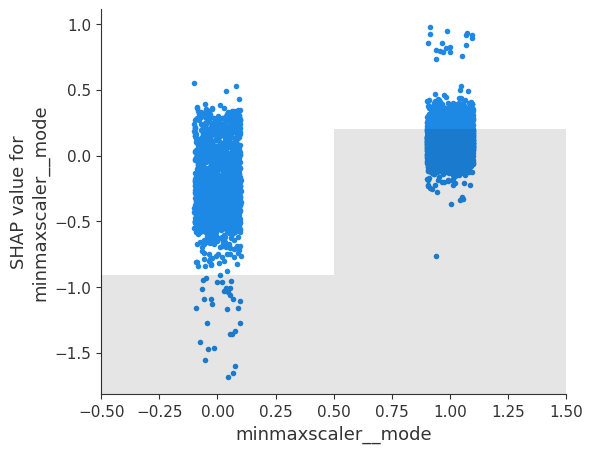

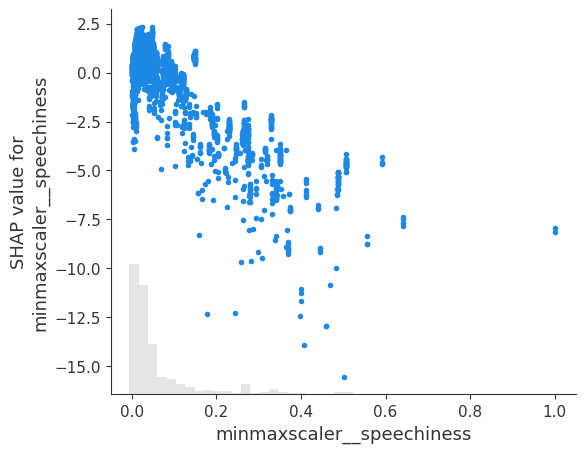

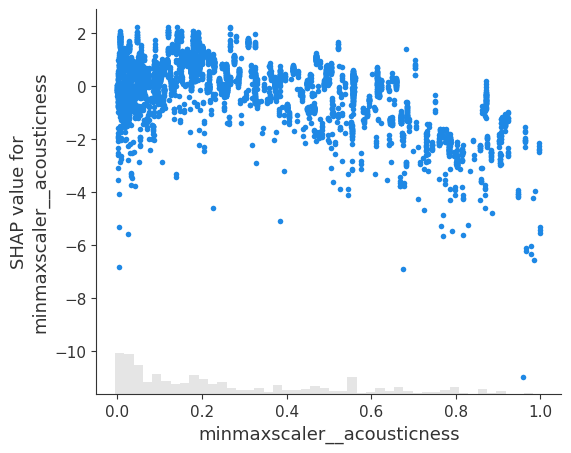

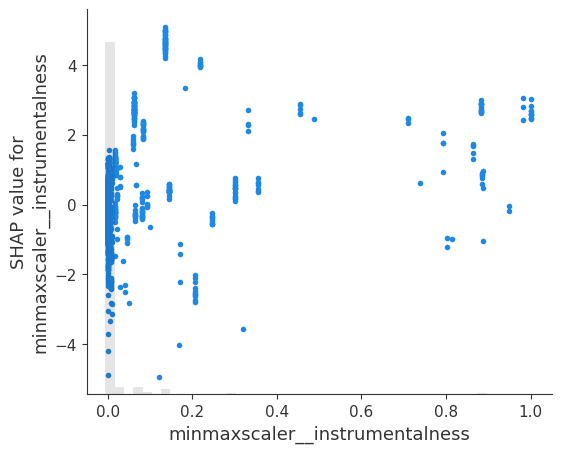

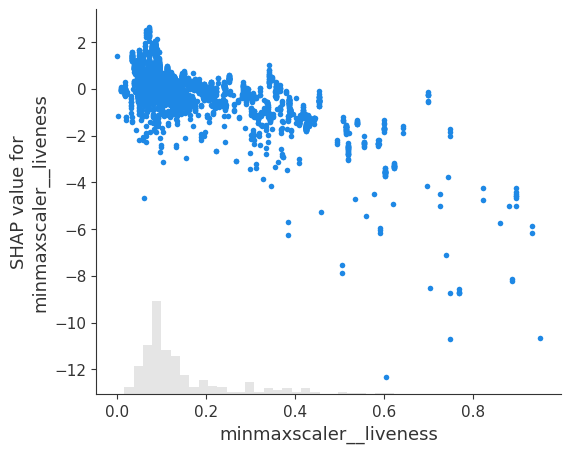

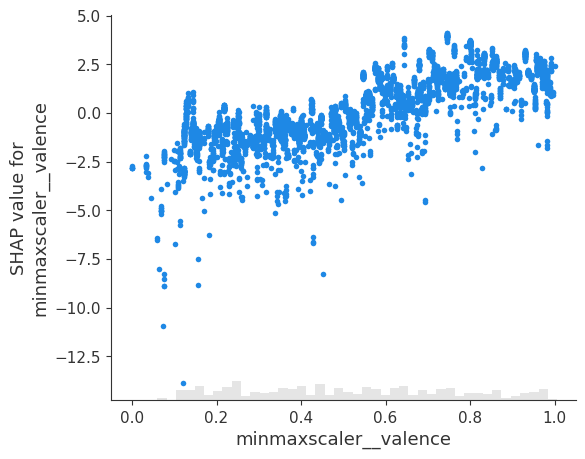

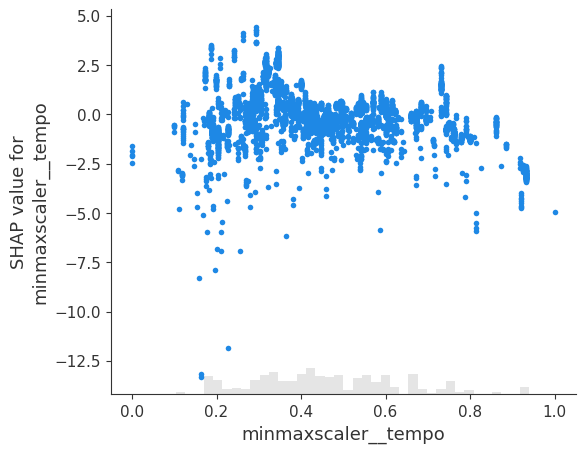

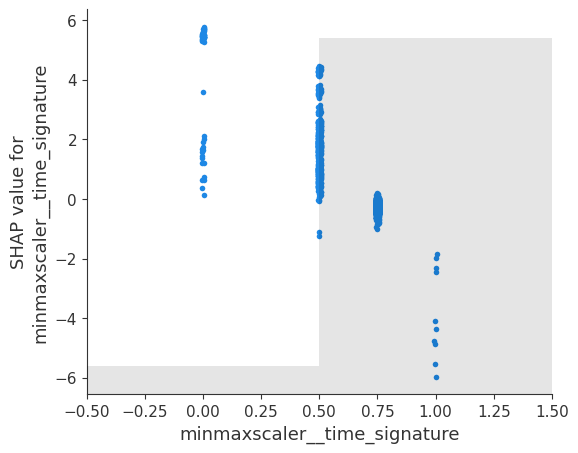

In [22]:
# Plots how each feature affects the model's output
for i in range(len(feature_names)):
    shap.plots.scatter(shap_values[:, i])

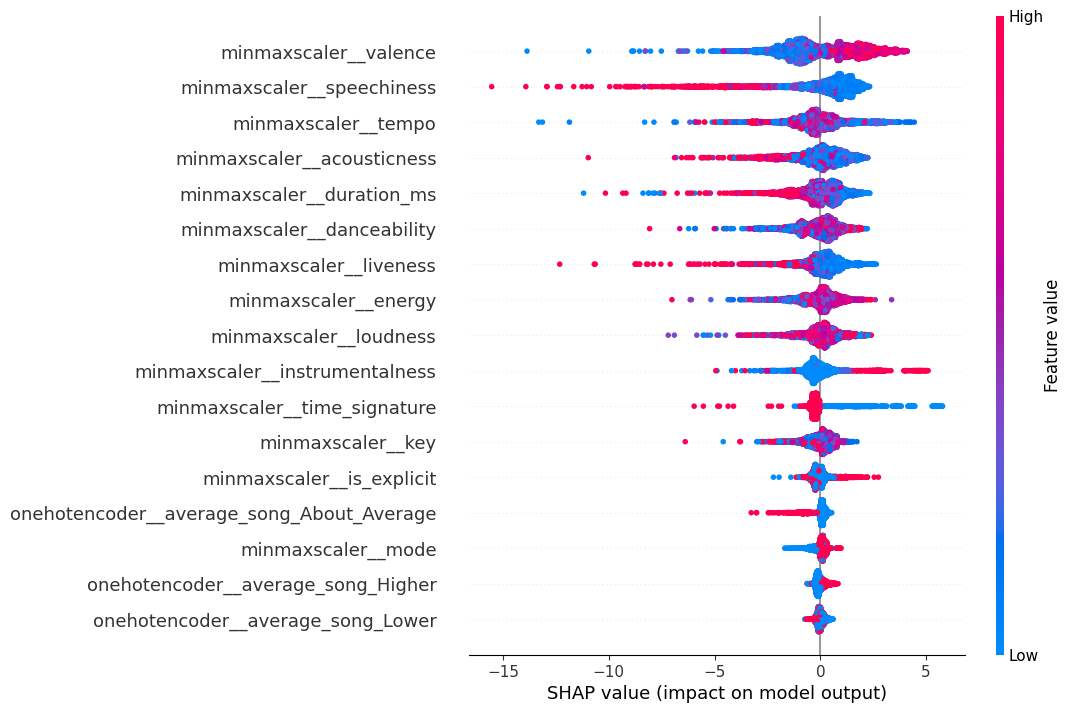

In [23]:
# Plots the summary of the model's predictions
shap.plots.beeswarm(shap_values, max_display=50)

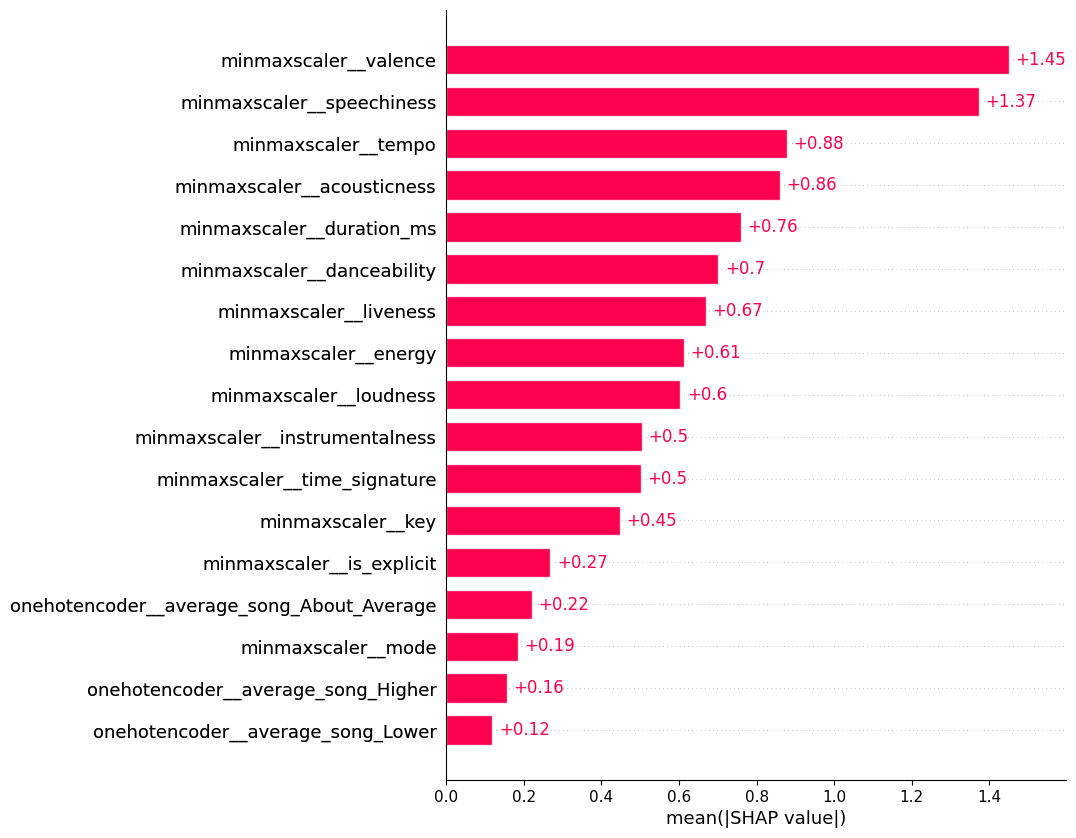

In [24]:
# Bar chart of features that most affect the model's output
shap.plots.bar(shap_values, max_display=50)